# Vision-Language Models (VLMs) for Street View Imagery

**Author:** Alexander Michels

This notebook explores the use of a Vision-Language Model (VLM) for analyzing street view imagery. VLMs are models that combine a Large Language Model (LLM, think ChatGPT, LLama, etc.) with a vision encoder allowing the model to "see".

Specifically, we will explore the SmolVLM model: https://huggingface.co/blog/smolvlm This model can be run on I-GUIDE Platform or even your local computer because it has been optimized to be small, fast, and memory-efficient!

In [1]:
import time
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.image_utils import load_image

/cvmfs/iguide.purdue.edu/software/conda/geoai-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**You can ignore the TqdmWarning above, it won't stop what we are trying to do.**

We will use a pre-trained VLM model from [HuggingFace](https://huggingface.co/). HuggingFace is a powerful AI community for sharing apps, models, data, and more!

In [2]:
# this notebook was tested on CPU and works fine, but should work with GPUs as well!
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cpu


In [3]:
processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-Instruct")
model = AutoModelForImageTextToText.from_pretrained("HuggingFaceTB/SmolVLM-Instruct",
                                                torch_dtype=torch.bfloat16,
                                                _attn_implementation="flash_attention_2" if DEVICE == "cuda" else "eager").to(DEVICE)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 657/657 [00:00<00:00, 4236.59it/s]


To demonstrate the model, we will load one of our sample street view images:

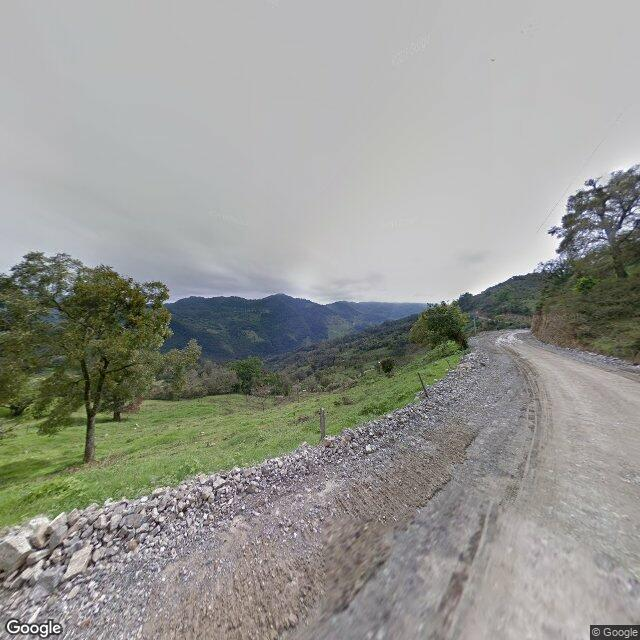

In [4]:
# Load images
image1 = load_image("data/kaggle-samples/0.png")
image1

We will start with a relatively simple prompt: Can you briefly describe this image?

To do this, we can use the code below to create the message and send it to the model:

In [5]:
# Create input messages
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "In 10 words or less, describe this image."}  # keeping it short to reduce compute time.
        ]
    },
]

# Prepare inputs
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image1], return_tensors="pt")
inputs = inputs.to(DEVICE)

Then we can ask the model to generate and provide it with a token limit on its output.

An AI model understands text by breaking it down into "tokens". You can think of tokens as like syllables or bite-sized chunks that helps the model better understand what a word means. For example, a word like "apple" might need only one token, but more complex words like "unbelievable" might get broken down into a few components like "un" + "believ" + "able". The `max_new_tokens` sets a limit on how much the model will generate.

**The next couple cells will take a few minutes because it is doing a LOT of computation!**

In [6]:
# Generate outputs
start = time.time()  # so we can track elapsed time
generated_ids = model.generate(**inputs, max_new_tokens=50)
end = time.time()
print(f"Computation took {end-start}")

Computation took 1559.5679314136505


In [7]:
# decode the outputs
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

In [8]:
print(generated_texts[0])

User:<row_1_col_1><row_1_col_2><row_1_col_3><row_1_col_4>
<row_2_col_1><row_2_col_2><row_2_col_3><row_2_col_4>
<row_3_col_1><row_3_col_2><row_3_col_3><row_3_col_4>
<row_4_col_1><row_4_col_2><row_4_col_3><row_4_col_4>

<global-img>In 10 words or less, describe this image.
Assistant: Road, trees, mountains, sky.


Let's turn these last few cells of code into a single function to make things a bit cleaner!

In [9]:
def prompt_model(model, prompt, images, max_new_tokens=30):
    """
    Takes a VLM model, text prompt (str) and list of images and provides the response.

    This just streamlines the code we have above. 
    """
    start = time.time()
    # Create input messages
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt}
            ]
        },
    ]
    _prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=_prompt, images=images, return_tensors="pt")
    inputs = inputs.to(DEVICE)
    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_texts = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
    ) 
    end = time.time()
    print(f"Computation took {end-start}")
    return(generated_texts[0])

The brief description is pretty good!

Let's give the VLM a more objective task like object detection. There is a bit of an art and science to prompt engineering, but we will use a simple prompt:

In [10]:
my_prompt = "How many trees are in this image? Provide only an integer."
print(prompt_model(model, my_prompt, [image1]))

Computation took 1573.020717382431
User:<row_1_col_1><row_1_col_2><row_1_col_3><row_1_col_4>
<row_2_col_1><row_2_col_2><row_2_col_3><row_2_col_4>
<row_3_col_1><row_3_col_2><row_3_col_3><row_3_col_4>
<row_4_col_1><row_4_col_2><row_4_col_3><row_4_col_4>

<global-img>How many trees are in this image? Provide only an integer.
Assistant: 2.


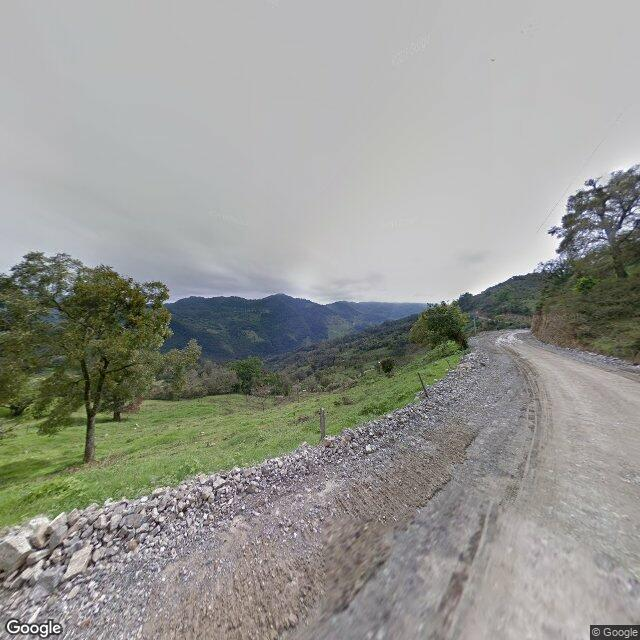

In [11]:
image1

You may have heard of the old addage: "don't miss the forest through the trees". Here, the VLM missed all of the trees in the forest! 

Of course this is a trick question that we wouldn't expect anyone to get right. Counting the individual trees in the forest with this quality of image is likely not possible, but it did identify the trees in the foreground.

Let's try this with the UTD image (or feel free to use your own street view image, just upload it and replace the path in `load_image`!):

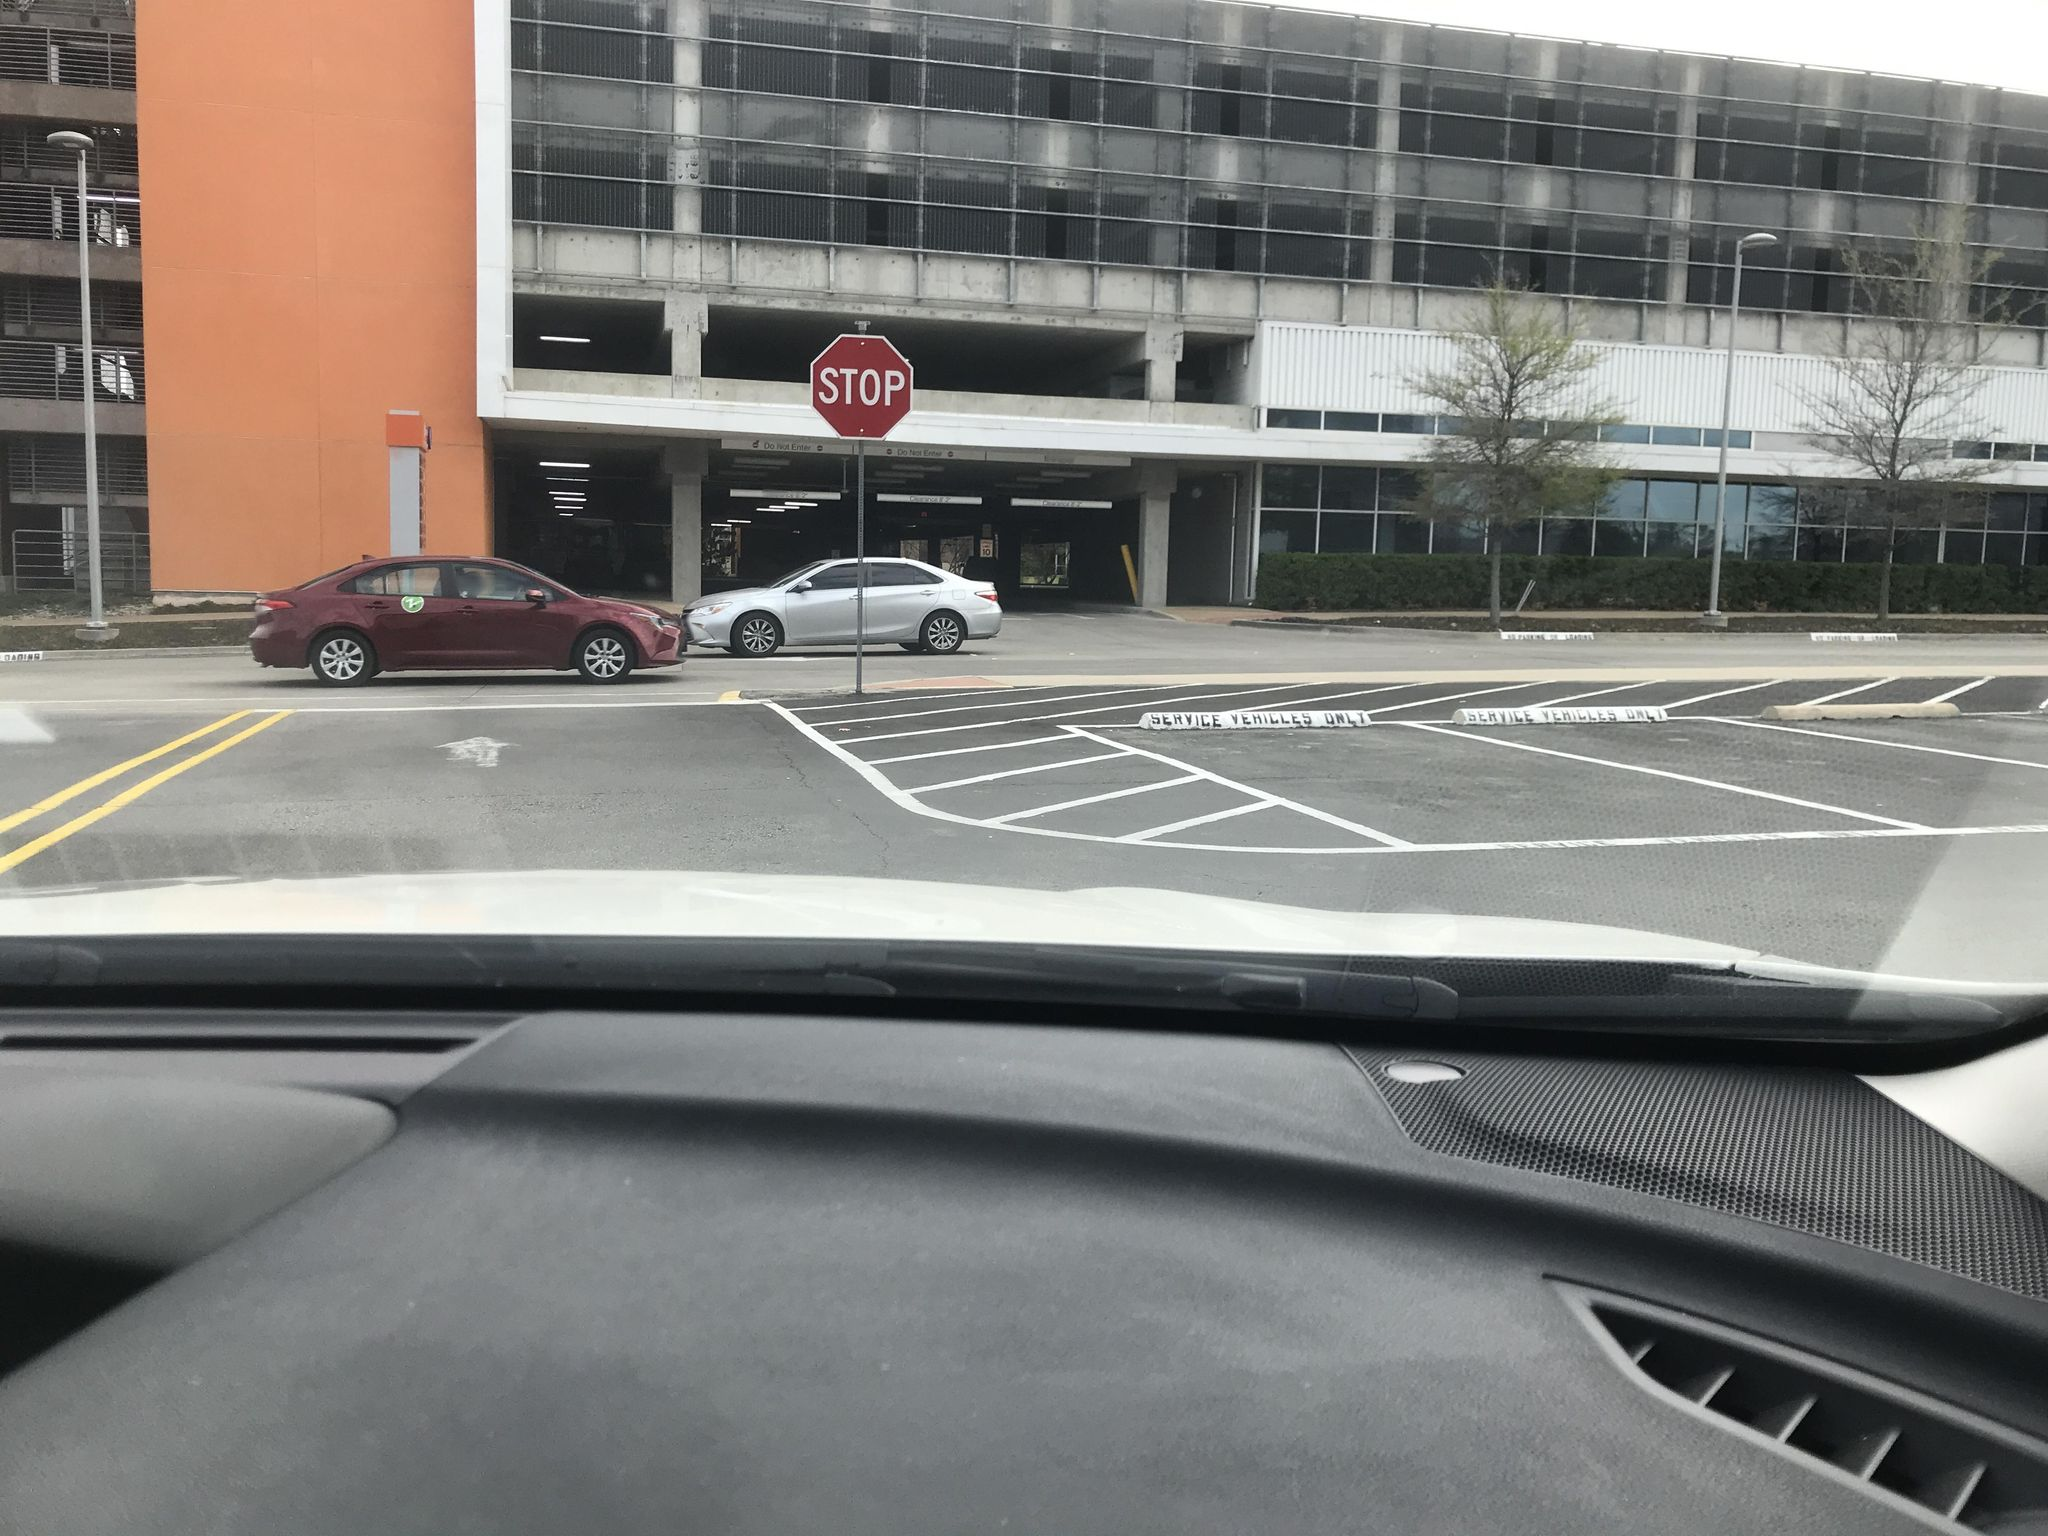

In [12]:
UTD_image = load_image("data/UTD.jpeg")
utd_prompt = "Briefly describe this image."
UTD_image

In [13]:
print(prompt_model(model, utd_prompt, [UTD_image]))

Computation took 1180.6859202384949
User:<row_1_col_1><row_1_col_2><row_1_col_3><row_1_col_4>
<row_2_col_1><row_2_col_2><row_2_col_3><row_2_col_4>
<row_3_col_1><row_3_col_2><row_3_col_3><row_3_col_4>

<global-img>Briefly describe this image.
Assistant: A red stop sign is in front of a parking garage. A red car and a silver car are parked in front of the stop sign.
